## Тема 1. Моделирование геометрической вероятности
> Два друга договариваются встретиться в кафе где-то с 12:00 до 13:00. Каждый приходит в случайный момент и ждет 15 минут. Если друг не пришел в течение 15 минут - он уходит. Какова вероятность того что они встретятся?

### Теория
В задаче время прихода первого друга - $x$, а второго - $y$. Поскольку каждый из них может прийти в любой момент заданного промежутка времени, пару ($x,y$) можно представить точкой на координатной плоскости.

Все возможные значения $x$ и $y$ образуют квадрат $T\times T$

$0 \le x \le 60, \qquad 0 \le y \le 60$

Тогда: $S = 60\times 60 = 3600$

### Решение на Python

Условие встречи: $|x - y| \le 15$

In [58]:
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

def meeting(count):
    side = 60 #60 минут
    fig, ax = plt.subplots(figsize = (5,5))
    ax.add_patch(Rectangle((0,0), side, side, facecolor='cyan'))
    line = np.linspace(0, 60, 100)
    ax.plot(line, line, color='red', linestyle='--') # идельная встреча
    y_lower = np.clip(line-15, 0, side)
    y_upper = np.clip(line+15, 0, side)
    ax.fill_between(line, y_lower, y_upper, facecolor='yellow', alpha=0.6) # зона 15 минут
    X = np.random.uniform(0, side, count) # Первый друг
    Y = np.random.uniform(0, side, count) # Второй
    plt.scatter(X, Y, marker='', c='black')
    inside = len([d for d in zip(X,Y) if abs(d[0]-d[1]) <= 15])
    print(f"Из {count} встреч благоприятными оказались {inside}. Вероятность = {inside/count}")

Из 1000 встреч благоприятными оказались 460. Вероятность = 0.46


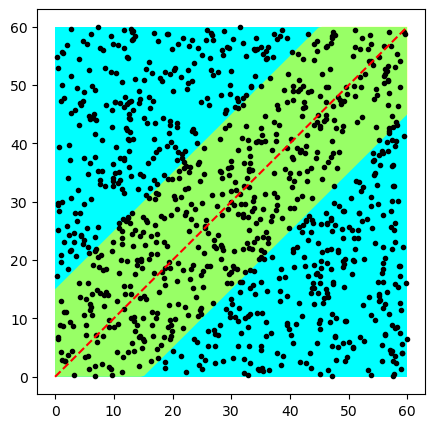

In [60]:
meeting(1000)

### Аналитическое вычисление 

В нашем примере с $T = 60$, ожиданием 15 минут, вне области встречи находятся два одинаковых прямоугольных треугольника

Площадь одного:
$S_1 = 45^2/2$

Двух: $Sнебл = 45^2 = 2025$

$S_A = 60^2 - 45^2 = 3600 - 2025 = 1575$

Вероятность: $P(A)$